In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, f1_score
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Dataset

In [4]:
data_origin_cate = pd.read_excel("./widsdatathon2025/TRAIN_NEW/TRAIN_CATEGORICAL_METADATA_new.xlsx")

data_origin_quan = pd.read_excel("./widsdatathon2025/TRAIN_NEW/TRAIN_QUANTITATIVE_METADATA_new.xlsx")

data_origin_funct_matrix = pd.read_csv("./widsdatathon2025/TRAIN_NEW/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv")

data_origin_solution = pd.read_excel("./widsdatathon2025/TRAIN_NEW/TRAINING_SOLUTIONS.xlsx")

data_dict = pd.read_excel("./widsdatathon2025/Data Dictionary.xlsx")

data_test_cate = pd.read_excel("./widsdatathon2025/TEST/TEST_CATEGORICAL.xlsx")

data_test_quan = pd.read_excel("./widsdatathon2025/TEST/TEST_QUANTITATIVE_METADATA.xlsx")

data_test_funct_matrix = pd.read_csv("./widsdatathon2025/TEST/TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv")

In [5]:
data_training_funct_matrix = data_origin_funct_matrix
data_training_solution = data_origin_solution

In [6]:
final_data_cat = pd.merge(data_origin_cate, data_origin_quan, on = 'participant_id')
final_data_mat = pd.merge(final_data_cat, data_origin_funct_matrix, on = 'participant_id')
final_data = pd.merge(final_data_mat, data_origin_solution, on = 'participant_id')
final_data

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ,...,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn,ADHD_Outcome,Sex_F
0,00aIpNTbG5uh,2019,4,1.0,0.0,3.0,21.0,45.0,NaN,NaN,...,-0.280312,0.037560,0.423037,0.242453,0.336213,0.402338,0.327915,0.539032,1,0
1,00fV0OyyoLfw,2017,1,0.0,9.0,2.0,21.0,0.0,21.0,45.0,...,-0.332783,-0.332711,0.556939,0.475578,0.429196,0.457970,0.312571,0.595978,1,0
2,04X1eiS79T4B,2017,1,1.0,2.0,2.0,9.0,0.0,NaN,NaN,...,-0.002132,-0.175586,0.679183,0.290292,0.486680,0.255208,0.575017,0.605182,0,1
3,05ocQutkURd6,2018,1,3.0,8.0,2.0,18.0,10.0,18.0,0.0,...,-0.199576,-0.216457,0.519074,0.298586,0.415466,0.511607,0.361204,0.446613,0,1
4,06YUNBA9ZRLq,2018,1,0.0,1.0,2.0,12.0,0.0,NaN,NaN,...,-0.141012,-0.002865,0.515169,0.336139,0.316430,0.442230,0.177079,0.378278,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,zwjJWCRzKhDz,2019,4,1.0,1.0,3.0,12.0,NaN,15.0,5.0,...,0.112789,0.211312,0.601190,0.587116,0.312695,0.485938,0.189102,0.354333,0,1
1209,zwXD5v17Rx01,2018,1,0.0,0.0,3.0,21.0,40.0,21.0,40.0,...,0.253990,0.198741,0.648260,0.055241,0.491985,0.118676,0.404331,0.537121,1,0
1210,zWzLCi3NTBTd,2018,3,2.0,3.0,3.0,21.0,40.0,21.0,35.0,...,0.044653,0.234887,0.538475,0.024265,0.472322,0.095624,0.205326,0.182633,1,1
1211,Zy9GTHDxUbXU,2019,4,0.0,1.0,3.0,18.0,35.0,18.0,45.0,...,-0.035955,-0.062152,0.706214,0.183288,0.104987,0.420463,0.152727,0.706737,1,0


In [7]:
final_data_test = pd.merge(data_test_quan, data_test_funct_matrix, on = 'participant_id')
print(len(final_data_test.columns))
final_data = pd.merge(data_origin_quan, data_origin_funct_matrix, on = 'participant_id')
final_data = pd.merge(final_data, data_origin_solution, on = 'participant_id')
len(final_data.columns)

19919


19921

In [8]:
df = pd.DataFrame(data = {'Percent_missing' : final_data.isnull().sum() * 100 / len(final_data)}, copy = False)
df[df['Percent_missing'] > 0]

,Percent_missing
EHQ_EHQ_Total,1.071723
ColorVision_CV_Score,1.896125
APQ_P_APQ_P_CP,0.989283
APQ_P_APQ_P_ID,0.989283
APQ_P_APQ_P_INV,0.989283
APQ_P_APQ_P_OPD,0.989283
APQ_P_APQ_P_PM,0.989283
APQ_P_APQ_P_PP,0.989283
SDQ_SDQ_Conduct_Problems,0.741962
SDQ_SDQ_Difficulties_Total,0.741962


# ThuyDuc

## Adjustment for connectome matrix

### Calculate R^2 for connectome matrix

In [9]:
participant = data_origin_funct_matrix['participant_id']
matrix = data_origin_funct_matrix.iloc[:, 1:]
matrix = matrix**2
matrix_adjusted = pd.concat([participant, matrix], axis = 1)
matrix_adjusted

,participant_id,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,70z8Q2xdTXM3,0.049698,0.278681,0.184871,0.003655,0.320910,0.099441,0.258479,0.006129,0.276352,...,0.050618,0.157965,1.789005e-01,0.034093,0.093360,0.176694,0.000267,0.315691,0.222001,0.133386
1,WHWymJu6zNZi,0.377936,0.333224,0.246142,0.246618,0.163770,0.193357,0.015028,0.007302,0.014562,...,0.047326,0.000212,1.939562e-07,0.009303,0.206571,0.118278,0.027993,0.369246,0.303186,0.253186
2,4PAQp1M6EyAo,0.013650,0.210138,0.067966,0.408361,0.591880,0.195831,0.405909,0.036868,0.270795,...,0.117297,0.000447,1.431571e-03,0.005635,0.170331,0.085678,0.152885,0.213023,0.258991,0.389665
3,obEacy4Of68I,0.039875,0.566579,0.433336,0.330736,0.480065,0.417044,0.273268,0.169899,0.281795,...,0.010725,0.031795,4.451395e-02,0.000348,0.190369,0.351627,0.046744,0.116467,0.193875,0.311580
4,s7WzzDcmDOhF,0.051675,0.376098,0.386196,0.316601,0.542741,0.347879,0.071116,0.129361,0.090463,...,0.027211,0.000050,1.461771e-02,0.238236,0.243617,0.046380,0.044388,0.003119,0.014176,0.011723
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,9gpepMI9sj5q,0.070375,0.304402,0.394783,0.419516,0.505176,0.017512,0.106411,0.125542,0.282141,...,0.016154,0.016845,8.939327e-02,0.013128,0.285273,0.014136,0.032867,0.032781,0.056814,0.332940
1209,FIDen5rdMc0v,0.000338,0.332570,0.278205,0.107232,0.344414,0.329119,0.090327,0.090663,0.435389,...,0.232531,0.025468,2.640547e-02,0.008695,0.096046,0.020684,0.047671,0.151579,0.108071,0.056855
1210,dlsMC4TXL4e8,0.051542,0.164559,0.000554,0.008665,0.004756,0.419352,0.581485,0.216326,0.039735,...,0.143872,0.016123,3.751756e-02,0.046003,0.184759,0.091289,0.010978,0.733378,0.091959,0.132233
1211,syeyZjEx8FUx,0.036042,0.566823,0.709743,0.667550,0.672722,0.628769,0.423709,0.238636,0.336640,...,0.045052,0.003085,4.925528e-02,0.040992,0.363188,0.232387,0.159491,0.139686,0.078344,0.468450


### Extract connectome matrix for Sex_F to examine

In [10]:
matrix_adjusted_merge_adhd_sex_f = pd.merge(matrix_adjusted, data_origin_solution, on = 'participant_id')

columns = matrix_adjusted_merge_adhd_sex_f.columns

len_column = len(columns)

columns_for_sex_f = list(columns[:len_column - 2]) + ['Sex_F']

data = matrix_adjusted_merge_adhd_sex_f[columns_for_sex_f]

# Connectome matrix for male and female
data_male = data[data['Sex_F'] == 0]
data_female = data[data['Sex_F'] == 1]


In [11]:
from sklearn.feature_selection import SelectKBest, f_classif

columns = data.columns
len_column = len(columns)

x = data[columns[1:len_column - 1]]
y = data['Sex_F']

selector = SelectKBest(f_classif, k = len(columns[1:len_column - 1]))
selector.fit(x, y)

final = pd.DataFrame(data = {'F-score': selector.scores_, 'p-value': selector.pvalues_}, index = columns[1:len_column - 1])
final_sort = final.sort_values(by = 'p-value', ascending = True)
final_sort[final_sort['p-value'] <= 0.00005]

,F-score,p-value
152throw_184thcolumn,33.219743,1.043343e-08
158throw_191thcolumn,27.810005,1.583863e-07
75throw_185thcolumn,26.363041,3.293567e-07
89throw_91thcolumn,25.846923,4.278574e-07
80throw_185thcolumn,24.931596,6.809667e-07
172throw_188thcolumn,23.990932,1.098897e-06
75throw_80thcolumn,23.595797,1.343969e-06
184throw_185thcolumn,21.370720,4.190635e-06
60throw_75thcolumn,21.172609,4.638609e-06
32throw_87thcolumn,21.129015,4.743476e-06


In [12]:
# Extract the features with p-value <= 0.0005
connectome_features_sex = final_sort[final_sort['p-value'] <= 0.00005].index
connectome_features_sex

Index(['152throw_184thcolumn', '158throw_191thcolumn', '75throw_185thcolumn',
       '89throw_91thcolumn', '80throw_185thcolumn', '172throw_188thcolumn',
       '75throw_80thcolumn', '184throw_185thcolumn', '60throw_75thcolumn',
       '32throw_87thcolumn', '24throw_145thcolumn', '87throw_185thcolumn',
       '191throw_197thcolumn', '164throw_189thcolumn', '61throw_151thcolumn',
       '182throw_194thcolumn', '42throw_59thcolumn', '180throw_195thcolumn',
       '146throw_194thcolumn', '24throw_144thcolumn', '70throw_75thcolumn',
       '22throw_148thcolumn', '0throw_4thcolumn', '131throw_140thcolumn',
       '120throw_121thcolumn', '0throw_132thcolumn', '75throw_172thcolumn',
       '16throw_19thcolumn', '82throw_172thcolumn', '146throw_189thcolumn'],
      dtype='object')

### Extract connectome matrix for ADHD to examine

In [13]:
matrix_adjusted_merge_adhd_sex_f = pd.merge(matrix_adjusted, data_origin_solution, on = 'participant_id')

columns = matrix_adjusted_merge_adhd_sex_f.columns

len_column = len(columns)

columns_for_ADHD_outcome = list(columns[:len_column - 2]) + ['ADHD_Outcome']

data = matrix_adjusted_merge_adhd_sex_f[columns_for_ADHD_outcome]

# Connectome matrix for male and female
data_ADHD_1 = data[data['ADHD_Outcome'] == 1]
data_ADHD_0 = data[data['ADHD_Outcome'] == 0]

data_ADHD_1.head()

,participant_id,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,...,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn,ADHD_Outcome
0,70z8Q2xdTXM3,0.049698,0.278681,0.184871,0.003655,0.320910,0.099441,0.258479,0.006129,0.276352,...,0.157965,1.789005e-01,0.034093,0.093360,0.176694,0.000267,0.315691,0.222001,0.133386,1
1,WHWymJu6zNZi,0.377936,0.333224,0.246142,0.246618,0.163770,0.193357,0.015028,0.007302,0.014562,...,0.000212,1.939562e-07,0.009303,0.206571,0.118278,0.027993,0.369246,0.303186,0.253186,1
2,4PAQp1M6EyAo,0.013650,0.210138,0.067966,0.408361,0.591880,0.195831,0.405909,0.036868,0.270795,...,0.000447,1.431571e-03,0.005635,0.170331,0.085678,0.152885,0.213023,0.258991,0.389665,1
3,obEacy4Of68I,0.039875,0.566579,0.433336,0.330736,0.480065,0.417044,0.273268,0.169899,0.281795,...,0.031795,4.451395e-02,0.000348,0.190369,0.351627,0.046744,0.116467,0.193875,0.311580,1
4,s7WzzDcmDOhF,0.051675,0.376098,0.386196,0.316601,0.542741,0.347879,0.071116,0.129361,0.090463,...,0.000050,1.461771e-02,0.238236,0.243617,0.046380,0.044388,0.003119,0.014176,0.011723,1


In [14]:
from sklearn.feature_selection import SelectKBest, f_classif

data = matrix_adjusted_merge_adhd_sex_f[columns_for_ADHD_outcome]

columns = data.columns

len_column = len(columns)

x = data[columns[1:len_column - 1]]
y = data['ADHD_Outcome']

selector = SelectKBest(f_classif, k = len(columns[1:len_column - 1]))
selector.fit(x, y)

final = pd.DataFrame(data = {'F-score': selector.scores_, 'p-value': selector.pvalues_}, index = columns[1:len_column - 1])
final_sort = final.sort_values(by = 'p-value', ascending = True)
final_sort[final_sort['p-value'] <= 0.0005]

,F-score,p-value
78throw_170thcolumn,18.452153,0.000019
166throw_184thcolumn,16.824730,0.000044
78throw_189thcolumn,14.821830,0.000124
34throw_130thcolumn,14.650053,0.000136
34throw_134thcolumn,14.647255,0.000136
76throw_170thcolumn,14.435530,0.000152
104throw_119thcolumn,14.050577,0.000186
80throw_134thcolumn,13.182342,0.000294
24throw_143thcolumn,13.080956,0.000311
1throw_171thcolumn,12.616961,0.000397


In [15]:
# Extract the features with p-value <= 0.0005
connectome_features_ADHD = final_sort[final_sort['p-value'] <= 0.0005].index
connectome_features_ADHD

Index(['78throw_170thcolumn', '166throw_184thcolumn', '78throw_189thcolumn',
       '34throw_130thcolumn', '34throw_134thcolumn', '76throw_170thcolumn',
       '104throw_119thcolumn', '80throw_134thcolumn', '24throw_143thcolumn',
       '1throw_171thcolumn', '17throw_35thcolumn', '132throw_166thcolumn'],
      dtype='object')

## Train model based on chosen features

'SDQ_SDQ_Emotional_Problems'

In [16]:
# features without connectome matrix
# features_adhd = ['SDQ_SDQ_Hyperactivity', 'SDQ_SDQ_Externalizing', 
#                  'SDQ_SDQ_Difficulties_Total', 'SDQ_SDQ_Generating_Impact', 
#                  'SDQ_SDQ_Conduct_Problems']
features_adhd = ['SDQ_SDQ_Hyperactivity']
features_sex_f = ['SDQ_SDQ_Hyperactivity', 'SDQ_SDQ_Externalizing', 
                  'SDQ_SDQ_Prosocial', 
                  'ColorVision_CV_Score']

# features from connectome matrix
features_connectome_adhd = connectome_features_ADHD.to_list()

features_connectome_sex = connectome_features_sex.to_list()

In [17]:
len(features_connectome_sex)

30

## Models

### Preparation

In [18]:
# Get features and labels
features_sex_f_completed = features_connectome_sex + ['Sex_F']
features_adhd_completed = features_adhd + ['ADHD_Outcome']
#features_connectome_adhd -- used when needed
#features_sex_f -- used when needed

In [19]:
# Get datasets with selected features

# For ADHD
dataset_adhd_train = final_data[features_adhd_completed]
dataset_adhd_test = final_data_test[features_adhd_completed[:-1]] # this dataset does not have label

# For sex_F
dataset_sex_f_train = final_data[features_sex_f_completed]
dataset_sex_f_test = final_data_test[features_sex_f_completed[:-1]] # this dataset does not have label

In [20]:
# Drop missing values
dataset_adhd_train = dataset_adhd_train.dropna()
dataset_adhd_test = dataset_adhd_test.fillna(dataset_adhd_test.mean())

dataset_sex_f_train = dataset_sex_f_train.dropna()
dataset_sex_f_test = dataset_sex_f_test.fillna(dataset_sex_f_test.mean())

In [21]:
# Split data into training and validation dataset
# For ADHD_Outcome
X_train_adhd, X_val_adhd, y_train_adhd, y_val_adhd = train_test_split(dataset_adhd_train.iloc[:, :-1], dataset_adhd_train.iloc[:, -1], test_size=0.2, random_state=42, stratify=dataset_adhd_train.iloc[:, -1])
# For Sex_F
X_train_sex, X_val_sex, y_train_sex, y_val_sex = train_test_split(dataset_sex_f_train.iloc[:, :-1], dataset_sex_f_train.iloc[:, -1], test_size=0.2, random_state=42, stratify=dataset_sex_f_train.iloc[:, -1])

In [22]:
# Normalization
# For ADHD_Outcome
scaler = StandardScaler()
scaler.fit(X_train_adhd)  # Fit on training data

X_train_adhd = scaler.transform(X_train_adhd)  # Transform training data
y_train_adhd = y_train_adhd.values  # Extract labels

X_test_adhd = scaler.transform(dataset_adhd_test) # Transform test data

X_val_adhd = scaler.transform(X_val_adhd)  # Transform validation data
y_val_adhd = y_val_adhd.values  # Extract labels




# For Sex_F
# scaler = StandardScaler()
# scaler.fit(X_train_sex)  # Fit on training data

# X_train_sex = scaler.transform(X_train_sex)  # Transform training data
y_train_sex = y_train_sex.values

# X_test_sex = scaler.transform(dataset_sex_f_test)  # Transform test data

# X_val_sex = scaler.transform(X_val_sex) # Transform validation data
y_val_sex = y_val_sex.values


### Comparison between val_datasets and test_datasets

**For AHDH**

In [23]:
X_test_adhd_dataframe = pd.DataFrame(X_test_adhd, columns=dataset_adhd_test.columns)
X_val_adhd_dataframe = pd.DataFrame(X_val_adhd, columns=dataset_adhd_train.columns[:-1])
X_train_adhd_dataframe = pd.DataFrame(X_train_adhd, columns=dataset_adhd_train.columns[:-1])

<Axes: >

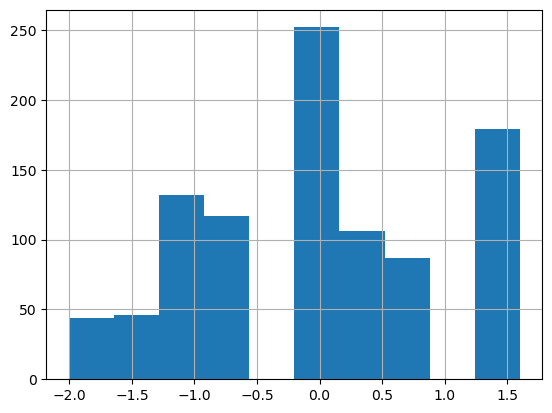

In [24]:
X_train_adhd_dataframe['SDQ_SDQ_Hyperactivity'].hist()

<Axes: >

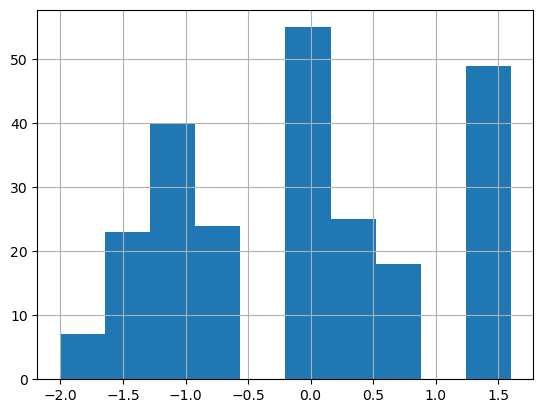

In [25]:
X_val_adhd_dataframe['SDQ_SDQ_Hyperactivity'].hist()

<Axes: >

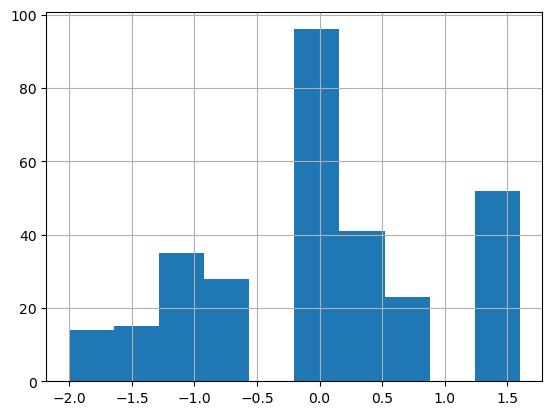

In [26]:
X_test_adhd_dataframe['SDQ_SDQ_Hyperactivity'].hist()

**For Sex_F**

In [27]:
dataset_sex_f_test

,152throw_184thcolumn,158throw_191thcolumn,75throw_185thcolumn,89throw_91thcolumn,80throw_185thcolumn,172throw_188thcolumn,75throw_80thcolumn,184throw_185thcolumn,60throw_75thcolumn,32throw_87thcolumn,...,70throw_75thcolumn,22throw_148thcolumn,0throw_4thcolumn,131throw_140thcolumn,120throw_121thcolumn,0throw_132thcolumn,75throw_172thcolumn,16throw_19thcolumn,82throw_172thcolumn,146throw_189thcolumn
0,0.547129,0.588023,0.338244,0.560199,0.182932,0.463627,0.367989,0.165945,0.147834,0.077829,...,0.337274,0.359696,0.524369,0.254050,0.469715,0.349538,0.495823,0.532927,0.227401,-0.374211
1,0.449301,0.548124,0.591926,0.547476,0.089414,0.594062,0.460738,-0.212800,0.747655,-0.448056,...,0.501179,0.223876,0.363003,0.156696,0.634244,0.335267,0.464783,0.656534,0.271271,-0.138425
2,0.518382,-0.008419,0.298361,0.522821,0.315228,0.350363,0.595997,-0.075048,0.587856,-0.218344,...,0.425440,0.024825,0.196852,0.343913,0.442282,-0.094358,-0.123907,0.260611,-0.031543,-0.083757
3,0.558193,0.496905,0.399904,0.442197,0.363648,0.034632,0.124153,0.290043,0.349304,-0.329818,...,0.420497,0.024083,0.471840,0.288182,0.627508,0.317404,-0.211521,0.238030,0.207866,0.061950
4,0.530633,0.051431,0.570251,0.231883,0.080026,0.032527,0.048005,0.295728,-0.003743,-0.333806,...,0.122462,0.364188,0.363193,0.311230,0.840121,0.336943,0.051304,0.745095,0.243998,0.302329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,0.420279,0.200290,0.315521,0.242723,0.293854,-0.056121,0.138150,0.112435,0.613205,-0.199905,...,0.340372,-0.035749,0.292066,0.184291,0.808335,0.241386,0.232617,0.392842,0.034790,-0.093185
300,0.440110,0.375118,0.244929,0.642470,-0.013178,0.333574,-0.234489,0.216619,0.234834,-0.316561,...,0.598777,-0.007057,0.463090,-0.184358,0.359370,-0.147314,0.501341,-0.148049,0.350637,-0.362148
301,0.568549,0.164555,0.250503,0.318381,-0.048048,-0.118331,0.131871,0.357705,0.104240,-0.156359,...,0.363114,0.350964,0.435582,0.535532,0.575710,0.482092,0.192610,0.638735,0.236453,-0.090455
302,0.516874,0.535933,0.371591,0.331229,0.388146,0.181071,0.543013,0.216195,0.519720,-0.572330,...,0.502713,-0.192404,0.442141,0.064622,0.692551,0.221489,0.152423,0.850219,-0.259684,-0.237109


In [28]:
X_test_sex_dataframe = pd.DataFrame(dataset_sex_f_test, columns=dataset_sex_f_test.columns)
X_val_sex_dataframe = pd.DataFrame(X_val_sex, columns=dataset_sex_f_train.columns[:-1])
X_train_sex_dataframe = pd.DataFrame(X_train_sex, columns=dataset_sex_f_train.columns[:-1])

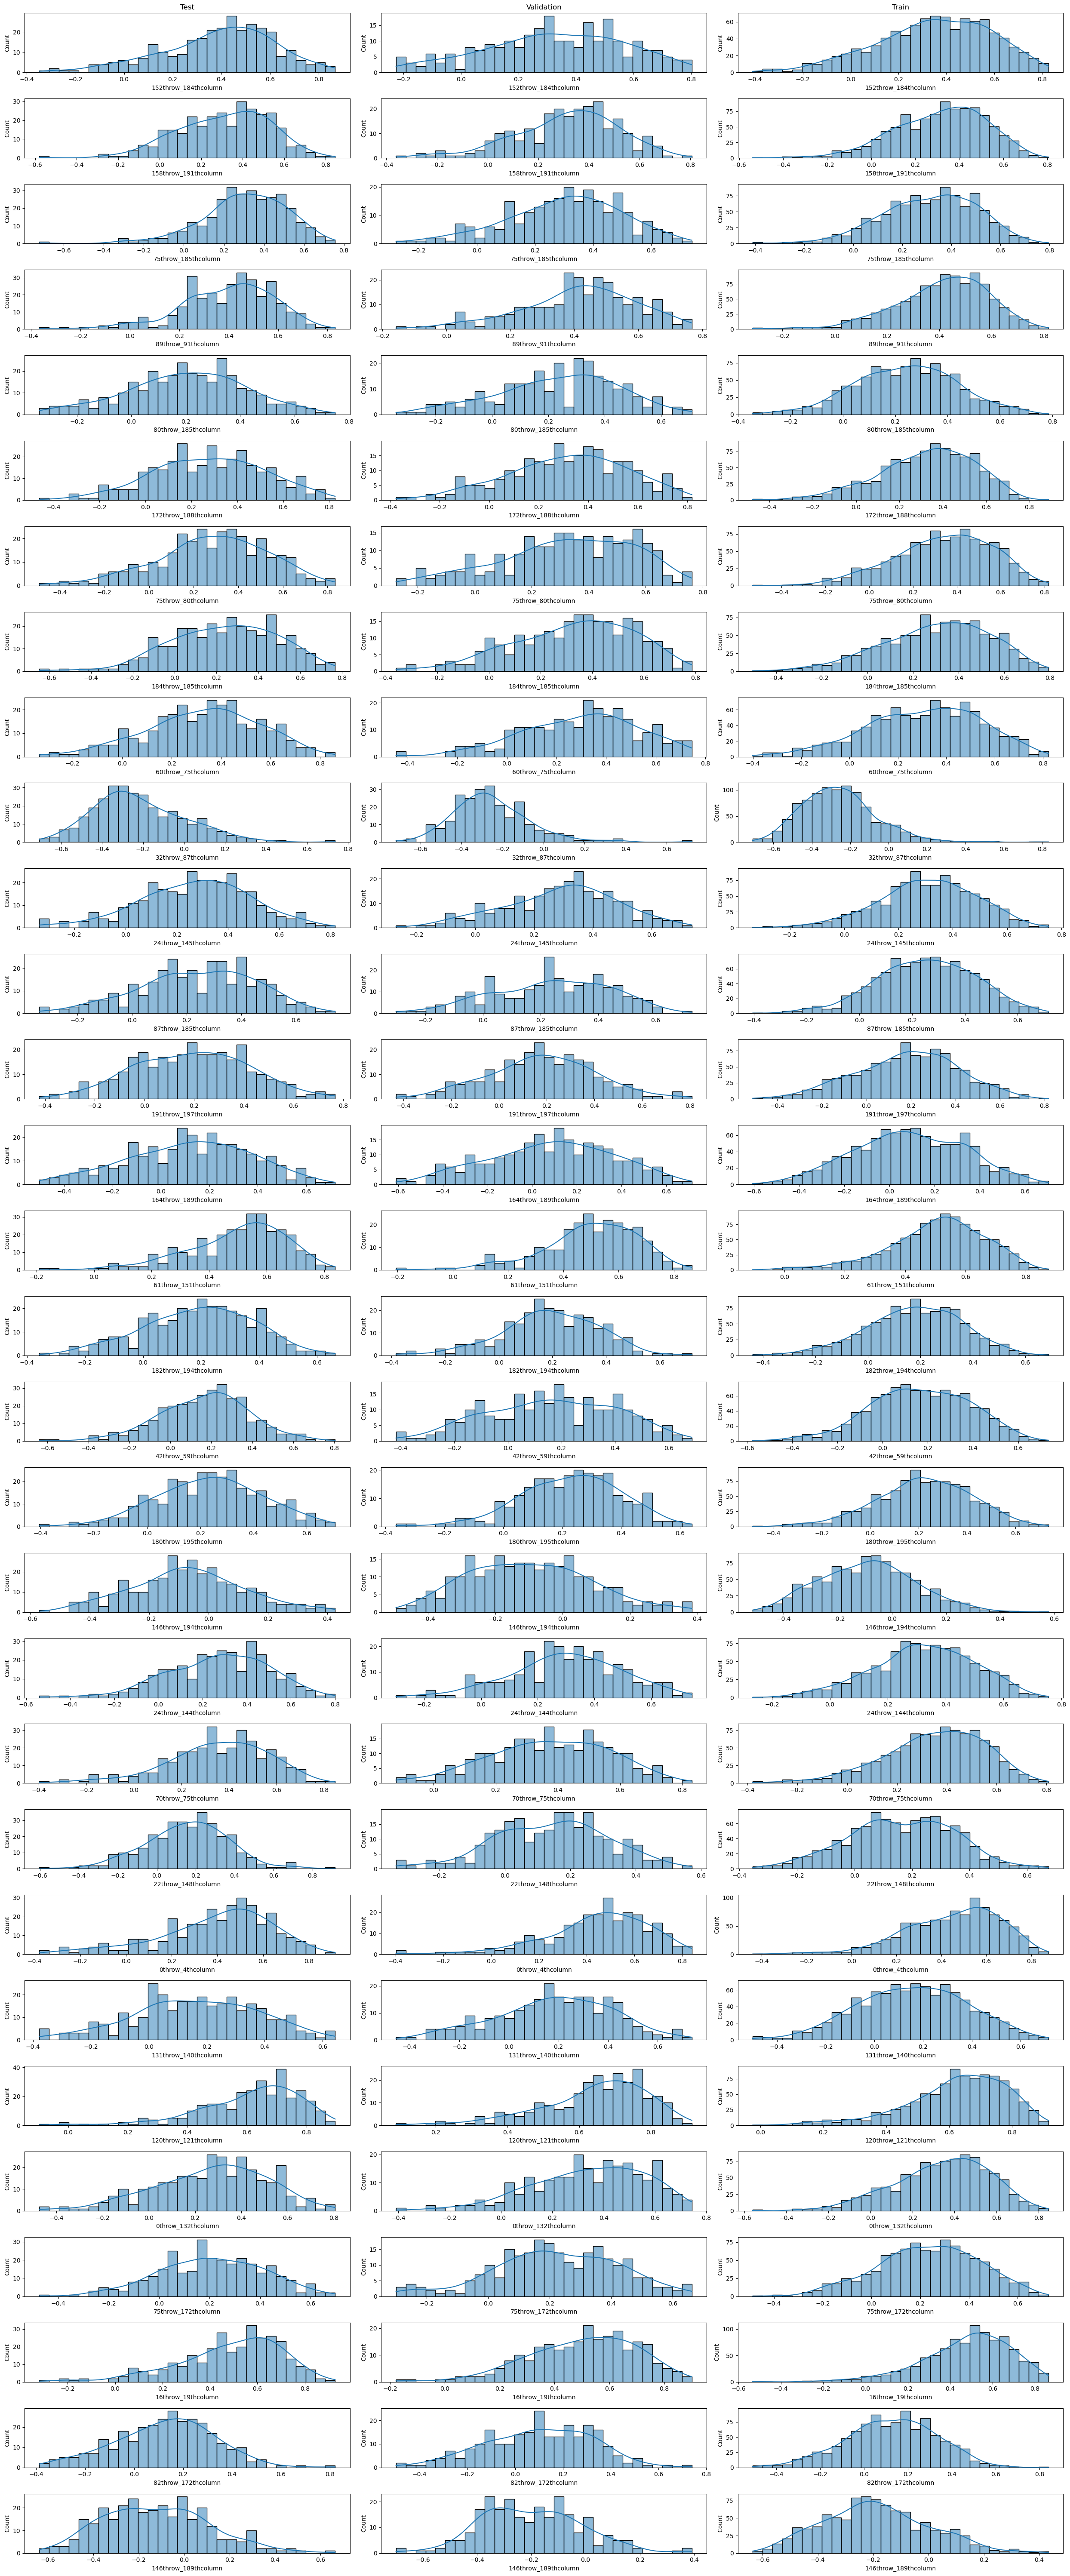

In [29]:
fig, axs = plt.subplots(30, 3, figsize=(25, 60))

columns_train = X_train_sex_dataframe.columns
columns_val = X_val_sex_dataframe.columns
columns_test = X_test_sex_dataframe.columns

for i in range(30):
    sns.histplot(data = X_test_sex_dataframe, x = columns_test[i], ax = axs[i][0], bins = 30, kde= True)
    sns.histplot(data = X_val_sex_dataframe, x = columns_val[i], ax = axs[i][1], bins = 30, kde= True)
    sns.histplot(data = X_train_sex_dataframe, x = columns_train[i], ax = axs[i][2], bins = 30, kde= True)

axs[0][0].set_title('Test')
axs[0][1].set_title('Validation')
axs[0][2].set_title('Train')
plt.tight_layout()
plt.show()
    

### Test different models

**Create ModelEvaluator to test model**

In [30]:
class ModelEvaluator:
    def __init__(self, models : list, models_name : list[str], X_train_adhd=None, y_train_adhd=None, X_val_adhd=None, y_val_adhd=None, X_train_sex=None, y_train_sex=None, X_val_sex=None, y_val_sex=None):
        self.models = models
        self.models_name = models_name

        self.X_train_adhd = X_train_adhd
        self.y_train_adhd = y_train_adhd
        self.X_val_adhd = X_val_adhd
        self.y_val_adhd = y_val_adhd

        self.X_train_sex = X_train_sex
        self.y_train_sex = y_train_sex
        self.X_val_sex = X_val_sex
        self.y_val_sex = y_val_sex

    def evaluate(self):
        acc_adhd_collect = []
        f1_adhd_collect = []
        acc_sex_collect = []
        f1_sex_collect = []

        # MultiIndex for columns
        columns = pd.MultiIndex.from_tuples([
            ('ADHD_Outcome', 'Accuracy'),
            ('ADHD_Outcome', 'F1 Score'),
            ('Sex F', 'Accuracy'),
            ('Sex F', 'F1 Score')])
        
        df = pd.DataFrame(columns=columns, index=self.models_name)

        for index, model in enumerate(self.models):
            # Evaluate ADHD_Outcome
            model.fit(self.X_train_adhd, self.y_train_adhd)
            y_pred_adhd = model.predict(self.X_val_adhd)

            acc_adhd = accuracy_score(self.y_val_adhd, y_pred_adhd)
            f1_adhd = f1_score(self.y_val_adhd, y_pred_adhd)

            # print(f"{self.models_name[index]} - ADHD_Outcome - Accuracy: {acc_adhd}")
            # print(f"{self.models_name[index]} - ADHD_Outcome - F1 Score: {f1_adhd}")
            
            # Evaluate Sex_F
            model.fit(self.X_train_sex, self.y_train_sex)
            y_pred_sex = model.predict(self.X_val_sex)

            acc_sex = accuracy_score(self.y_val_sex, y_pred_sex)
            f1_sex = f1_score(self.y_val_sex, y_pred_sex)

            # print(f"{self.models_name[index]} - Sex_F - Accuracy: {acc_sex}")
            # print(f"{self.models_name[index]} - Sex_F - F1 Score: {f1_sex}")

            acc_adhd_collect.append(acc_adhd)
            f1_adhd_collect.append(f1_adhd)

            acc_sex_collect.append(acc_sex)
            f1_sex_collect.append(f1_sex)
        
        # Add results to DataFrame
        df['ADHD_Outcome', 'Accuracy'] = acc_adhd_collect
        df['ADHD_Outcome', 'F1 Score'] = f1_adhd_collect
        df['Sex F', 'Accuracy'] = acc_sex_collect
        df['Sex F', 'F1 Score'] = f1_sex_collect

        return df


**Testing different models**

**Trước tiên chưa cần dùng đến các feature từ ma trận connectome cho ADHD_Outcome. Việc có cần dùng hay không phụ thuộc vào việc so sánh phân phối giữa test dataset và train dataset**

**Đối với Sex_F hiện tại chỉ sử dụng ma trận connectome, dùng thêm các feature SDQ nếu cần**

In [31]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier, HistGradientBoostingClassifier
from sklearn.ensemble import StackingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.linear_model import SGDClassifier, Perceptron
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier



ridge = RidgeClassifier(random_state=42, alpha = 0.4)
gaussian = GaussianNB()
decision_tree = DecisionTreeClassifier(random_state=42)
logistic_regression = LogisticRegression(random_state=42, max_iter=1000, C = 0.1)
random_forest = RandomForestClassifier(random_state=42)
extra_trees = ExtraTreesClassifier(random_state=42)
gradient_boosting = GradientBoostingClassifier(random_state=42)
hist_gradient_boosting = HistGradientBoostingClassifier(random_state=42)
sgd = SGDClassifier(random_state=42)
perceptron = Perceptron(random_state=42)
svc = SVC(random_state=42)
linear_svc = LinearSVC(random_state=42)
knn = KNeighborsClassifier()
adaboost = AdaBoostClassifier(random_state=42)
bagging = BaggingClassifier(random_state=42)

stacking = StackingClassifier(estimators=[
    ('ridge', ridge),
    ('gaussian', gaussian),
    ('decision_tree', decision_tree),
    ('logistic_regression', logistic_regression),
    ('random_forest', random_forest),
    ('extra_trees', extra_trees),
    ('gradient_boosting', gradient_boosting),
    ('hist_gradient_boosting', hist_gradient_boosting),
    ('sgd', sgd),
    ('perceptron', perceptron),
    ('svc', svc),
    ('linear_svc', linear_svc),
    ('knn', knn)
], final_estimator=RidgeClassifier(random_state=42))

voting = VotingClassifier(estimators=[
    ('ridge', ridge),
    ('gaussian', gaussian),
    ('decision_tree', decision_tree),
    ('logistic_regression', logistic_regression),
    ('random_forest', random_forest),
    ('extra_trees', extra_trees),
    ('gradient_boosting', gradient_boosting),
    ('hist_gradient_boosting', hist_gradient_boosting),
    ('sgd', sgd),
    ('perceptron', perceptron),
    ('svc', svc),
    ('linear_svc', linear_svc),
    ('knn', knn)
], voting='hard')


In [32]:
list_of_models = [ridge, gaussian, decision_tree, 
                  logistic_regression, random_forest, extra_trees, 
                  gradient_boosting, hist_gradient_boosting, sgd, 
                  perceptron, svc, linear_svc, 
                  knn, stacking, voting,
                  adaboost, bagging]
list_of_models_name = ['RidgeClassifier', 'GaussianNB', 'DecisionTreeClassifier', 
                       'LogisticRegression', 'RandomForestClassifier', 'ExtraTreesClassifier',
                       'GradientBoostingClassifier', 'HistGradientBoostingClassifier', 'SGDClassifier',
                        'Perceptron', 'SVC', 'LinearSVC', 
                        'KNeighborsClassifier', 'StackingClassifier', 'VotingClassifier',
                        'AdaBoostClassifier', 'BaggingClassifier']

In [33]:
evaluator = ModelEvaluator(list_of_models, list_of_models_name, 
                           X_train_adhd=X_train_adhd, y_train_adhd=y_train_adhd, X_val_adhd=X_val_adhd, y_val_adhd=y_val_adhd, X_train_sex=X_train_sex, 
                           y_train_sex=y_train_sex, X_val_sex=X_val_sex, y_val_sex=y_val_sex)
df = evaluator.evaluate()
df.sort_values(by=('ADHD_Outcome', 'F1 Score'), ascending=False)

ADHD_Outcome               Sex F          
                                   Accuracy  F1 Score  Accuracy  F1 Score
RidgeClassifier                    0.813278  0.866469  0.724280  0.510949
GaussianNB                         0.813278  0.866469  0.744856  0.617284
AdaBoostClassifier                 0.813278  0.866469  0.711934  0.539474
VotingClassifier                   0.813278  0.866469  0.748971  0.519685
StackingClassifier                 0.813278  0.866469  0.720165  0.514286
KNeighborsClassifier               0.813278  0.866469  0.683128  0.412214
LinearSVC                          0.813278  0.866469  0.728395  0.521739
SVC                                0.813278  0.866469  0.757202  0.542636
SGDClassifier                      0.813278  0.866469  0.728395  0.528571
HistGradientBoostingClassifier     0.813278  0.866469  0.732510  0.545455
GradientBoostingClassifier         0.813278  0.866469  0.732510  0.525547
ExtraTreesClassifier               0.813278  0.866469  0.748971  0.460177
RandomForestClassifier             0.813278  0.866469  0.720165  0.392857
LogisticRegression                 0.813278  0.866469  0.736626  0.438596
DecisionTreeClassifier             0.813278  0.866469  0.679012  0.486842
BaggingClassifier                  0.813278  0.866469  0.683128  0.393701
Perceptron                         0.717842  0.830000  0.691358  0.550898

## Neural Network

### For Sex_F

In [34]:
X_test_sex_tensor = torch.tensor(X_test_sex_dataframe.values, dtype=torch.float32)
X_train_sex_tensor = torch.tensor(X_train_sex.values, dtype=torch.float32)
X_val_sex_tensor = torch.tensor(X_val_sex.values, dtype=torch.float32)

y_train_sex_tensor = torch.tensor(y_train_sex, dtype=torch.float32)
y_val_sex_tensor = torch.tensor(y_val_sex, dtype=torch.float32)

### Dataset

In [35]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, index):
        
        return (self.X[index], self.y[index])


dataset_train_sex = CustomDataset(X_train_sex_tensor, y_train_sex_tensor)
dataset_val_sex = CustomDataset(X_val_sex_tensor, y_val_sex_tensor)

#dataset_test_sex = CustomDataset(X_test, y_test)
    

### Data Loader

In [36]:
Batch_Size = 64
dataloader_train = DataLoader(dataset_train_sex, batch_size=Batch_Size, shuffle=True)
dataloader_val = DataLoader(dataset_val_sex, batch_size=Batch_Size, shuffle=False)
#dataloader_test = DataLoader(dataset_test, batch_size=Batch_Size, shuffle=False)

### MLP Model

In [37]:
from typing import Literal, Optional
import math
import random
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, hidden_layer, output_size, hidden_size_changer : Literal['linear', 'fibonacci', 'logarit', 'random', 'increase_decrease'] | None = None, 
                 level_of_change : float = 1):
        super().__init__()
        
        # Set up layers
        layers = [
            nn.Linear(input_size, hidden_size),
            nn.Tanh()
        ]
        if hidden_size_changer == 'linear': # tăng tuyến tính
            hidden_size_new = int(hidden_size * level_of_change)
            for i in range(1, hidden_layer):

                layers.append(nn.Linear(hidden_size, hidden_size_new))
                layers.append(nn.Tanh()) 

                hidden_size = hidden_size_new
                hidden_size_new = int(hidden_size_new * level_of_change)

            layers.append(nn.Linear(hidden_size, output_size))

            

        elif hidden_size_changer == 'fibonacci':
            fibo_sizes = [hidden_size, hidden_size]  # Bắt đầu với hai giá trị đầu giống nhau

            # Tạo dãy Fibonacci cho số lượng hidden layers
            for _ in range(2, hidden_layer + 1):  # +1 vì còn output layer sau cùng
                fibo_sizes.append(fibo_sizes[-1] + fibo_sizes[-2])

            # Tạo các hidden layer với số node theo dãy Fibonacci
            for i in range(hidden_layer):
                layers.append(nn.Linear(fibo_sizes[i], fibo_sizes[i + 1]))
                layers.append(nn.Tanh())  # hoặc nn.ReLU() tùy theo bạn muốn

            # Layer cuối cùng nối đến output
            layers.append(nn.Linear(fibo_sizes[-1], output_size))

            

        elif hidden_size_changer == 'logarit':
            for i in range(1, hidden_layer + 1):
                hidden_size_new = int(hidden_size * level_of_change * math.log(i + 1))  # i + 1 để tránh log(0)
                
                layers.append(nn.Linear(hidden_size, hidden_size_new))
                layers.append(nn.Tanh())  # hoặc dùng ReLU nếu muốn

                hidden_size = hidden_size_new

            layers.append(nn.Linear(hidden_size, output_size))

            

        
        elif hidden_size_changer == 'random':
            for i in range(1, hidden_layer + 1):
                # Tăng ngẫu nhiên: từ hidden_size đến hidden_size * level_of_change
                min_size = min(hidden_size + 1, int(hidden_size * level_of_change))
                max_size = max(hidden_size + 1, int(hidden_size * level_of_change))

                hidden_size_new = random.randint(min_size, max_size)

                layers.append(nn.Linear(hidden_size, hidden_size_new))
                layers.append(nn.Tanh())  # hoặc dùng ReLU nếu muốn

                hidden_size = hidden_size_new

            layers.append(nn.Linear(hidden_size, output_size))

           
        
        elif hidden_size_changer == 'increase_decrease':
            mid = hidden_layer // 2  # vị trí chuyển từ tăng sang giảm

            hidden_sizes = [hidden_size]

            # Giai đoạn tăng
            for i in range(1, mid + 1):
                next_size = int(hidden_sizes[-1] * level_of_change)
                hidden_sizes.append(next_size)

            # Giai đoạn giảm
            for i in range(mid + 1, hidden_layer + 1):
                next_size = max(1, int(hidden_sizes[-1] / level_of_change))  # tránh về 0
                hidden_sizes.append(next_size)

            # Tạo các hidden layers
            for i in range(hidden_layer):
                layers.append(nn.Linear(hidden_sizes[i], hidden_sizes[i + 1]))
                layers.append(nn.Tanh())  # hoặc ReLU

            # Output layer
            layers.append(nn.Linear(hidden_sizes[-1], output_size))

            

        else:
            for _ in range(hidden_layer - 1):
                layers.append(nn.Linear(hidden_size, hidden_size))
                layers.append(nn.Tanh())
            
            layers.append(nn.Linear(hidden_size, output_size))
            
        
        
        self.classifier = nn.Sequential(*layers)
        
        # Initialize weights
        for layer in self.classifier:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)
    
    def forward(self, X):
        output = self.classifier(X)
        return output

### Training Session

In [38]:
train_lossess = []
val_lossess = []
f1_train = []
f1_val = []

In [39]:
epochs = 600

input_size = X_train_sex_tensor.shape[1]
hidden_size = 128
hidden_layer = 4
output_size = len(torch.unique(y_train_sex_tensor)) - 1
model = NeuralNetwork(input_size, hidden_size, hidden_layer, output_size, hidden_size_changer = 'increase_decrease', level_of_change = 1.5)

lr = 0.01
optimizer = optim.RMSprop(model.parameters(), lr=lr)

criterion = nn.BCEWithLogitsLoss()
model

NeuralNetwork(
  (classifier): Sequential(
    (0): Linear(in_features=30, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=192, bias=True)
    (3): Tanh()
    (4): Linear(in_features=192, out_features=288, bias=True)
    (5): Tanh()
    (6): Linear(in_features=288, out_features=192, bias=True)
    (7): Tanh()
    (8): Linear(in_features=192, out_features=128, bias=True)
    (9): Tanh()
    (10): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [40]:
best_f1_val = 0.0
best_model_state = None

train_lossess = []
val_lossess = []
f1_train = []
f1_val = []

for epoch in range(epochs):
    train_loss = 0
    val_loss = 0

    y_train_label_pred = []
    y_train_label_true = []

    y_val_label_pred = []
    y_val_label_true = []

    # Training session
    model.train()
    for X_train, y_train in dataloader_train:
        optimizer.zero_grad()  # Reset gradients

        # Forward pass
        y_pred = model(X_train)

        # Compute loss
        loss = criterion(y_pred.squeeze(), y_train)
        train_loss += loss.item()

        # Predictions
        y_train_label_true.extend(y_train.tolist())
        y_train_label_pred.extend([0 if y_pred[i] < 0.5 else 1 for i in range(len(y_pred))])

        # Backpropagation
        loss.backward()
        optimizer.step()

    train_loss /= len(dataloader_train)
    train_lossess.append(train_loss)

    f1_score_train = f1_score(y_train_label_true, y_train_label_pred)
    f1_train.append(f1_score_train)

    # Validation session
    model.eval()
    with torch.no_grad():
        for X_val, y_val in dataloader_val:
            y_pred = model(X_val)
            loss = criterion(y_pred.squeeze(), y_val)
            val_loss += loss.item()

            y_val_label_true.extend(y_val.tolist())
            y_val_label_pred.extend([0 if y_pred[i] < 0.5 else 1 for i in range(len(y_pred))])

        val_loss /= len(dataloader_val)
        val_lossess.append(val_loss)

        f1_score_val = f1_score(y_val_label_true, y_val_label_pred)
        f1_val.append(f1_score_val)

        # Save best model based on validation F1 score
        if f1_score_val > best_f1_val:
            best_f1_val = f1_score_val
            best_model_state = model.state_dict()
            print(f"Epoch {epoch+1}: New best F1 on val = {f1_score_val:.4f}, saving model...")

# # After training, save the best model weights to a file
# torch.save(best_model_state, 'best_model.pth')
# print("Training complete. Best model saved as 'best_model.pth'")

Epoch 1: New best F1 on val = 0.5092, saving model...


In [76]:
# After training, save the best model weights to a file
torch.save(best_model_state, 'best_model.pth')
print("Training complete. Best model saved as 'best_model.pth'")

Training complete. Best model saved as 'best_model.pth'


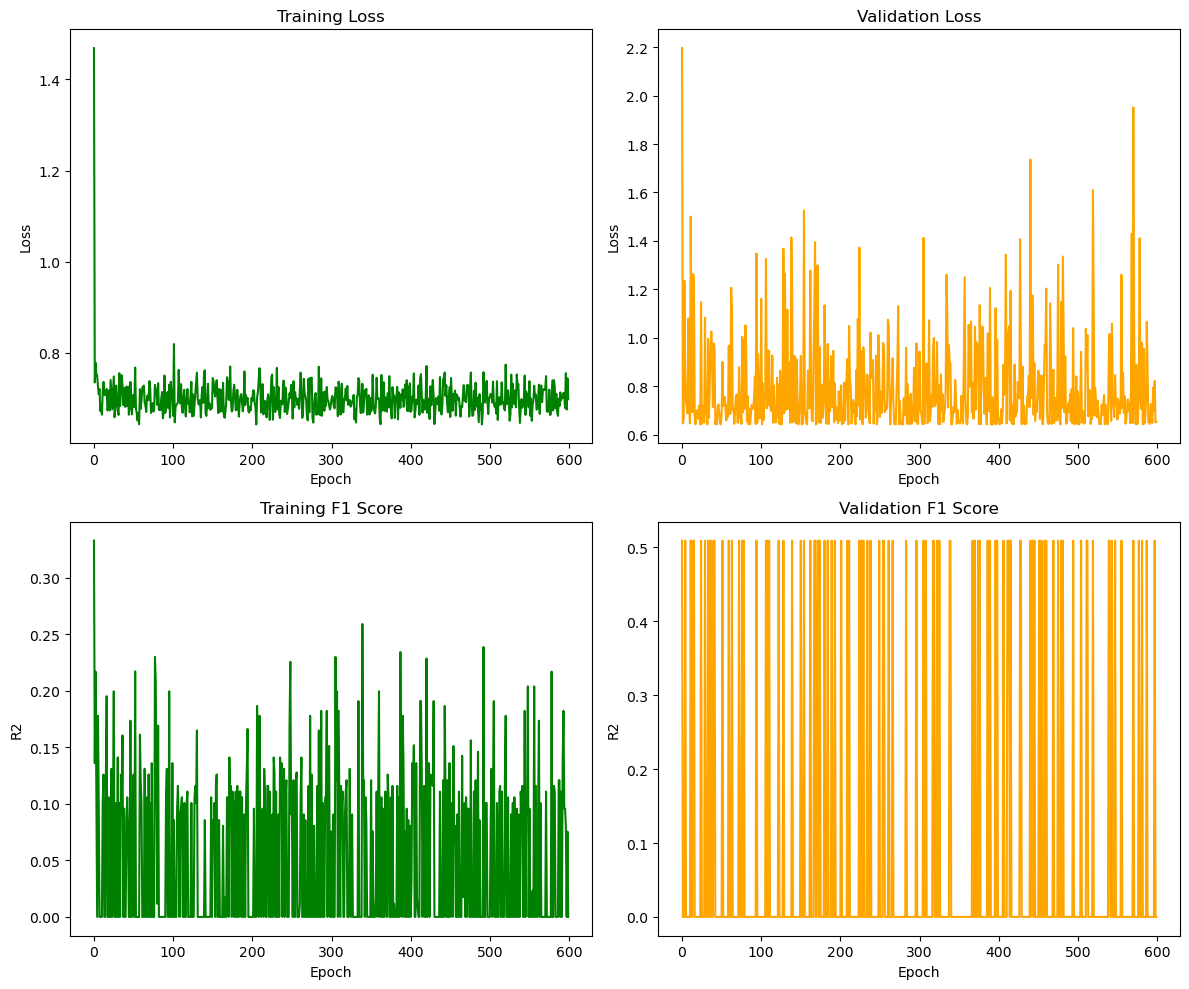

In [41]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax[0, 0].plot(train_lossess, color='green')
ax[0, 0].set(xlabel='Epoch', ylabel='Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot(val_lossess, color='orange')
ax[0, 1].set(xlabel='Epoch', ylabel='Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot(f1_train, color='green')
ax[1, 0].set(xlabel='Epoch', ylabel='R2')
ax[1, 0].set_title('Training F1 Score')

ax[1, 1].plot(f1_val, color='orange')
ax[1, 1].set(xlabel='Epoch', ylabel='R2')
ax[1, 1].set_title('Validation F1 Score')
plt.tight_layout()

plt.show()

### Submission

In [78]:
best_model_state = torch.load('best_model.pth', map_location=torch.device('cpu'))
model.load_state_dict(best_model_state)

<All keys matched successfully>

In [149]:
# For sex
y_test_sex_pred = model(X_test_sex_tensor)
y_test_sex_pred = torch.argmax(y_test_sex_pred, dim=1)
y_test_sex_pred

tensor([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
        1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
        0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1,
        1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
        0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,

In [151]:
X_test_adhd.shape

(304, 1)

In [112]:
np.vstack((X_train_adhd, X_val_adhd))

array([[ 0.15906185],
       [-0.92218449],
       [ 1.60072365],
       ...,
       [-0.92218449],
       [ 0.15906185],
       [-1.64301539]])

In [113]:
np.concatenate((y_train_adhd, y_val_adhd))

array([1, 0, 1, ..., 1, 1, 0])

In [ ]:
torch.cat((X_train_sex_tensor, X_val_sex_tensor), dim=0)

torch.Size([1213, 30])

In [120]:
y_pred = model(torch.cat((X_train_sex_tensor, X_val_sex_tensor), dim=0))
y_pred = torch.argmax(y_pred, dim=1)
y_pred = y_pred.numpy()
y_pred.shape

(1213,)

In [122]:
np.concatenate([y_train_sex, y_val_sex], axis=0).shape

(1213,)

In [123]:
f1_score(np.concatenate([y_train_sex, y_val_sex], axis=0), y_pred)


0.9113001215066828

In [ ]:
X_train_adhd.shape

In [152]:
# For ADHD
ridge = RidgeClassifier(random_state=42, alpha = 0.4)
ridge.fit(np.vstack((X_train_adhd, X_val_adhd)), np.concatenate((y_train_adhd, y_val_adhd)))
y_test_adhd_pred = ridge.predict(X_test_adhd)

In [153]:
# Save predictions to CSV
submission = final_data_test[['participant_id']].copy()
submission['ADHD_Outcome'] = y_test_adhd_pred  # Assuming the first column corresponds to ADHD_Outcome
submission['Sex_F'] = y_test_sex_pred

# Save results to CSV
submission.to_csv("submission-ThuyDuc.csv", index=False)
print("Predictions saved to submission.csv")

Predictions saved to submission.csv
